In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numba import njit
import awkward as ak
import ipywidgets as widgets
from IPython.display import display, clear_output
from ipywidgets import interact

ModuleNotFoundError: No module named 'numpy'

# <center> Wingspan data analysis

![Wingspan](https://images7.alphacoders.com/107/thumb-350-1079758.jpg)

## Raw data

In [ ]:
#Display float values with two decimals in pandas:
pd.options.display.float_format = "{:,.2f}".format 

#Load data:
my_points = pd.read_excel("./my_points.ods", engine="odf")
opp_points = pd.read_excel("./opponent_points.ods", engine="odf")

#my_points = pd.DataFrame(2 * np.random.rand(1000, 7), columns=['Birds','Bonus','Objectives','Eggs', 'Cached', 'Tucked', 'Total'])
#opp_points = pd.DataFrame(2.1* np.random.rand(1000, 7),columns=['Birds','Bonus','Objectives','Eggs', 'Cached', 'Tucked', 'Total'])


In [ ]:
#Include some features to have a closer look at the raw data:

#A range slider can be used to chose a range of points in a certain category.
#All games where the points in the category were within the range are displayed as a table.
#A dropdown menu is included to chose the category.

print('FlauschBu Daten:')

#Create a the range slider and define the features it has:
FlauschBu_slider = widgets.IntRangeSlider(
    value=[95, 110],
    min=1,
    max=110,
    step=1,
    description='Points',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

all_categories = list(Flausch_data.columns) #list all column enties in the data frame

#Create a the dropdown menu and define the features it has:
FlauschBu_dropdown = widgets.Dropdown(
    options= all_categories,
    value= all_categories[-1], #set the default value to the entry in the last column
    description='Category:',
    disabled=False,
)

#This function defines what happens when the slider and the dropdown menu obtain their input.
#The slider and the dropdown menu are the arguments.
#Function displays the data at alle locations where
#data[category] > smaller slider value and data[category] < larger slider value is true.

def interactive_FlauschBu(FlauschBu_slider, FlauschBu_dropdown):
    return (display(Flausch_data.loc[(Flausch_data[FlauschBu_dropdown] > FlauschBu_slider[0]) 
        & (Flausch_data[FlauschBu_dropdown] < FlauschBu_slider[1])]))

#The method interactive_output needs this control expression, that holds all widgets:
control = {'FlauschBu_slider' : FlauschBu_slider, 'FlauschBu_dropdown' : FlauschBu_dropdown}
#Now all the widgets can be placed in a box for better control over layout:
ui = widgets.VBox([widgets.HBox([FlauschBu_slider]), 
            widgets.HBox([FlauschBu_dropdown])])

#Us interactive_output by passing the function and the control expression for the widgets:
out = widgets.interactive_output(interactive_FlauschBu, control)
#Display the widgets and the output:
display(ui, out)

FlauschBu Daten:


Output()

In [ ]:
#Same as before for the other data set:
print('Bu Daten:')

Bu_slider = widgets.IntRangeSlider(
    value=[95, 110],
    min=1,
    max=110,
    step=1,
    description='Points',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

Bu_dropdown = widgets.Dropdown(
    options= all_categories,
    value= all_categories[-1],
    description='Category:',
    disabled=False,
)

def interactive_Bu(Bu_slider, Bu_dropdown):
    return (display(Data.loc[(Data[Bu_dropdown] > Bu_slider[0]) 
        & (Data[Bu_dropdown] < Bu_slider[1])]))

control = {'Bu_slider' : Bu_slider, 'Bu_dropdown' : Bu_dropdown}

ui = widgets.VBox([widgets.HBox([Bu_slider]), 
            widgets.HBox([Bu_dropdown])])

display(ui, widgets.interactive_output(interactive_Bu, control))

Bu Daten:


Output()

In [ ]:
#Define a toggle buttons with properties:
toggle_button = widgets.ToggleButton(
    value=False,
    description='Show more info',
    disabled=False,
    button_style='warning', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Description',
    icon='check' # (FontAwesome names without the `fa-` prefix)
)

out = widgets.Output(layout=widgets.Layout(border = '1px solid black'))

#Define a function that displays some additional information if the button is toggeled once
#and clears the output if the button is toggeled again.
#The additional informaton is generated by the pandas method data.describe().

def click_button(obj):
    with out:
        if obj['new']:  
            display('FlauschBu Daten:', Flausch_data.describe(), 'Bu Daten:', Data.describe())
        else:
            out.clear_output()

toggle_button.observe(click_button, 'value')
display(toggle_button)
display(out)

ToggleButton(value=False, button_style='warning', description='Show more info', icon='check', tooltip='Descrip…

Output(layout=Layout(border='1px solid black'))

### Distribution of the total Points of all games played:

Games played: 86
Mean for FlauschBu: 82.59302325581395 +/- 10.506443856848039
Mean for Bu: 78.51162790697674 +/- 10.68670882704472


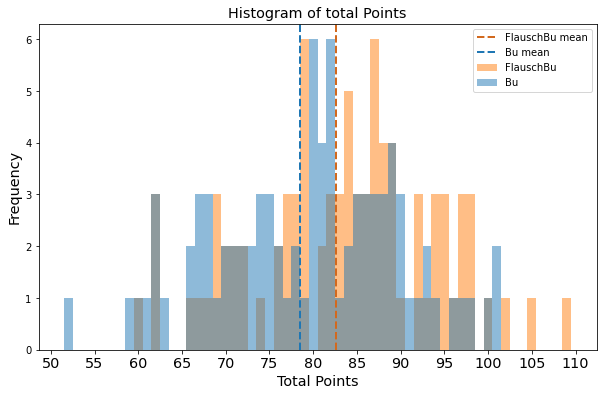

In [ ]:
#Calculate the mean of all categories at once since needed later:
Flausch_means = Flausch_data.mean()
Means = Data.mean()
Games_played = len(Flausch_data)

#Plot a histogram of the total points:
x = np.arange(50,120,5) #set the range for the plot manually

fig = plt.figure(figsize = [10,6])
ax1 = fig.add_subplot(1,1,1)
ax1.set_xticks(x)
ax1.set_xticklabels(x ,fontsize='x-large')
ax1.set_title("Histogram of total Points",fontsize='x-large')
ax1.set_ylabel("Frequency",fontsize='x-large')
ax1.set_xlabel("Total Points",fontsize='x-large')

Flausch_bins = np.arange(Flausch_data["Total"].min(), Flausch_data["Total"].max() + 1, 1)
Bu_bins = np.arange(Data["Total"].min(), Data["Total"].max() + 1, 1)

ax1.hist(Flausch_data["Total"], bins = Flausch_bins, alpha = 0.5, align='right', color = "C1", label = "FlauschBu")
ax1.hist(Data["Total"], bins = Bu_bins, alpha = 0.5, align='right', color = "C0", label = "Bu")

ax1.axvline(Flausch_means["Total"],c='chocolate', label="FlauschBu mean", linewidth = 2, linestyle = "dashed")
ax1.axvline(Means["Total"],c='C0', label="Bu mean", linewidth = 2, linestyle = "dashed")

plt.legend()
plt.plot()

print("Games played:", Games_played)
print("Mean for FlauschBu:", Flausch_means["Total"], "+/-", Flausch_data["Total"].std())
print("Mean for Bu:", Means["Total"], "+/-", Data["Total"].std())

### Absolute mean contribution of the individual categories:

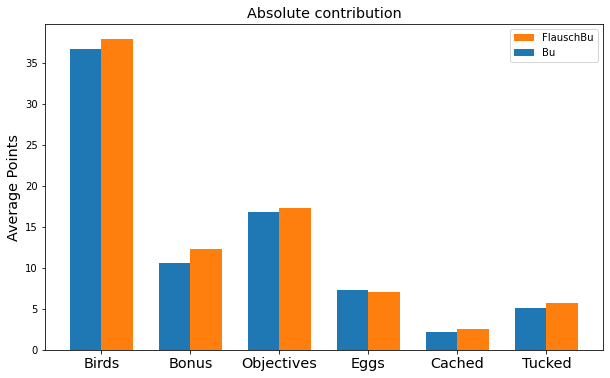

In [ ]:
#Compute the mean of each category except for the total number of points:
categories = ['Birds','Bonus','Objectives','Eggs', 'Cached', 'Tucked']

x = np.arange(1,len(categories) + 1,1)
width = 0.35

fig, ax2 = plt.subplots(1, 1, figsize = [10,6])
ax2.set_xticks(x)
ax2.set_xticklabels(categories ,fontsize='x-large') 
ax2.set_title("Absolute contribution",fontsize='x-large')
ax2.set_ylabel("Average Points",fontsize='x-large')
ax2.bar(x + width/2, Flausch_means[:-1], width, label='FlauschBu', color = "C1") #without total points
ax2.bar(x - width/2, Means[:-1], width, label='Bu', color = "C0") #without total points
ax2.legend()

plt.plot()
plt.show()

### Relative mean contribution of the individual categories:
(normalized to the average total points of each Bu)

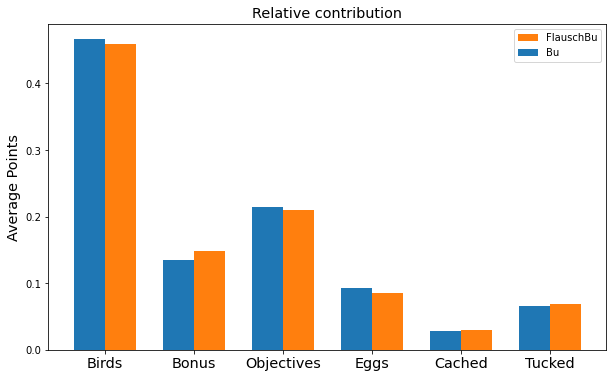

In [ ]:
#Same as before but normalized:
Flausch_means_norm = Flausch_means[:-1]/Flausch_means["Total"]
Means_norm = Means[:-1]/Means["Total"]

fig, ax2 = plt.subplots(1, 1, figsize = [10,6])
ax2.set_xticks(x)
ax2.set_xticklabels(categories ,fontsize='x-large') 
ax2.set_title("Relative contribution",fontsize='x-large')
ax2.set_ylabel("Average Points",fontsize='x-large')
ax2.bar(x + width/2, Flausch_means_norm, width, label='FlauschBu', color = "C1")
ax2.bar(x - width/2, Means_norm, width, label='Bu', color = "C0")
ax2.legend()

plt.plot()
plt.show()

### Games won:

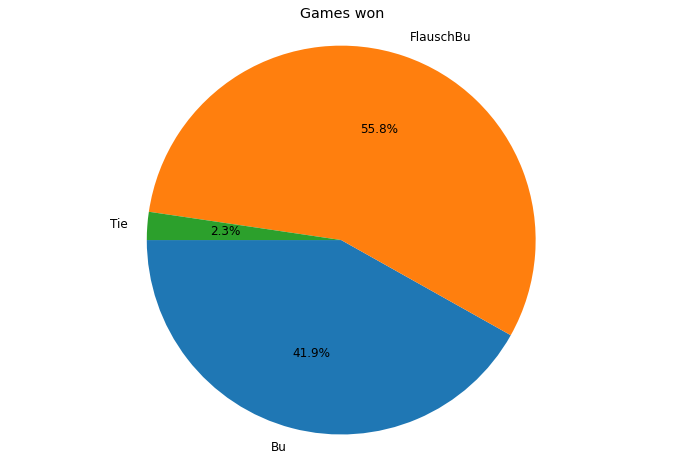

In [ ]:
#Count how many times each of the Bu's won a game and how often there was a tie:
#(Solution with loop and numba is not faster since loop only used once...)
point_difference = (Flausch_data["Total"] - Data["Total"])
Flausch_bu_victories = np.array((np.where(point_difference > 0))).size
Gleich_bu = np.array((np.where(point_difference == 0))).size
Bu_victories = Games_played - (Flausch_bu_victories + Gleich_bu)
    
#Define the properties of the pie Chart:
labels = 'Bu', 'FlauschBu', 'Tie'
sizes = [Bu_victories, Flausch_bu_victories, Gleich_bu]

fig = plt.figure(figsize = [12,8])
ax3 = fig.add_subplot(1,1,1)

ax3.set_title("Games won",fontsize='x-large')
ax3.pie(sizes, explode=None, labels=labels, autopct='%1.1f%%',shadow=False, startangle=180, textprops={'fontsize': 12})

ax3.axis('equal')
plt.show()

### Contribution of each categorie:

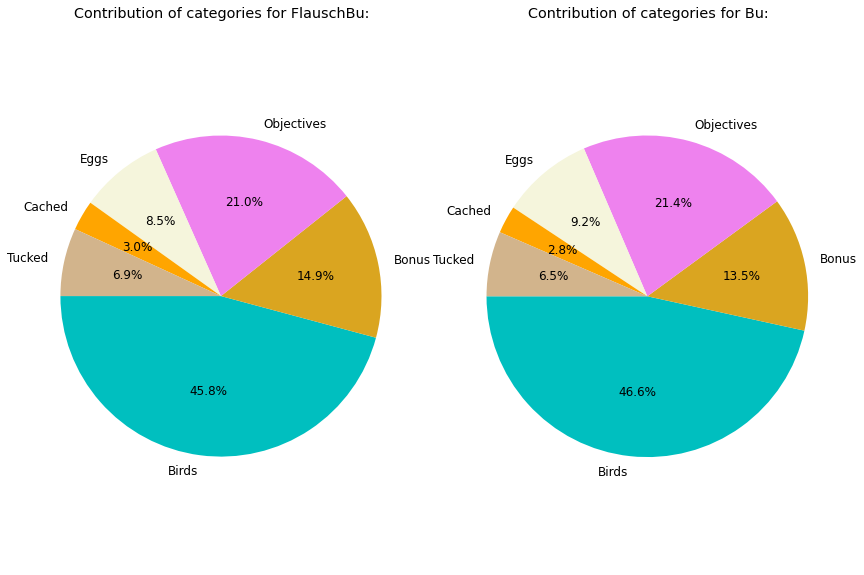

In [ ]:
colors=('c', 'goldenrod', 'violet', 'beige', 'orange', 'tan')

fig = plt.figure(figsize = [14,10])
ax4 = fig.add_subplot(1,2,1)
ax5 = fig.add_subplot(1,2,2)

ax4.set_title("Contribution of categories for FlauschBu:",fontsize='x-large')
ax5.set_title("Contribution of categories for Bu:",fontsize='x-large')
ax4.pie(Flausch_means[:-1], colors = colors, explode=None, labels=categories, 
        autopct='%1.1f%%',shadow=False, startangle=180, textprops={'fontsize': 12})
ax4.axis('equal')
ax5.pie(Means[:-1], colors = colors, explode=None, labels=categories, 
        autopct='%1.1f%%',shadow=False, startangle=180, textprops={'fontsize': 12})
ax5.axis('equal')

plt.show()

### Total points time development:

In [ ]:
#This gives a time evolution of the mean of any category.
#For this, the games are grouped in time spans.
#The amount of games included in a time span can be chosen with a slider.

#Note that the first 30 games were not documented time ordered, so they are only included 
#in the analysis for slider value >= 30.

#Create a slider for the interactive plot:
slider = widgets.IntSlider(
    value=5,
    min=1,
    max=len(Flausch_data)/2,
    step=1,
    description='Size',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

#Create a dropdown menu for the interactive plot
dropdown = widgets.Dropdown(
    options= all_categories,
    value= all_categories[-1],
    description='Category:',
    disabled=False,
)


#Pass the widget to the interactive plot (in this case a slider):
def interactive_plot(slider, dropdown):
    
    if (slider < 30):
        #obtain the correct grouping for a dataframe with 30 games less than total games: 
        Data_cut = Data[0: (Games_played - 30)] #just delete the last 30 games for simplicity
        Group_nr = Data_cut.index // slider

        #delete the first (!) 30 games and group:
        Flausch_data_grouped = (Flausch_data[30: Games_played]).groupby(by=Group_nr)
        Data_grouped = (Data[30: Games_played]).groupby(by=Group_nr)
        
        #create an x-axis with correct dimensions:
        amount_time_spans = (Data_grouped["Total"].mean()).size
        time_spans = np.arange(0, amount_time_spans, 1)

        #integrate dropdown menu?
        Flausch_totals = Flausch_data_grouped[dropdown].mean()
        Totals = Data_grouped[dropdown].mean()
        Flausch_std = Flausch_data_grouped[dropdown].std()
        Std = Data_grouped[dropdown].std()
        
#-------------------------------------------------------------------------------------------------
        #A few further output options:

        #Display the grouped dataframe (helpful to understand slider):
        #Data_grouped.apply(display)
        
        #Display the mean values of everything:
        #print("Grouped means for Bu:")
        #display(Data_grouped.mean())
        #print("Grouped means for FlauschBu:")
        #display(Flausch_data_grouped.mean())

        #You can access any column as in any pandas dataframe:
        #display((Flausch_data_grouped["Total"]).mean())
#---------------------------------------------------------------------------------------------------

    else:        
        #obtain correct grouping:
        Group_nr = Data.index // slider
        
        #just group:
        Flausch_data_grouped = Flausch_data.groupby(by=Group_nr)
        Data_grouped = Data.groupby(by=Group_nr)

        #create an x-axis with correct dimensions:
        amount_time_spans = (Data_grouped["Total"].mean()).size
        time_spans = np.arange(0, amount_time_spans, 1)

        Flausch_totals = Flausch_data_grouped["Total"].mean()
        Totals = Data_grouped["Total"].mean()
        Flausch_std = Flausch_data_grouped["Total"].std()
        Std = Data_grouped["Total"].std()

    fig, ax0 = plt.subplots(1, 1, figsize=(10,8))
    ax0.set_ylabel("Mean points for category",fontsize='x-large') 
    ax0.set_xlabel("Time span",fontsize='x-large') 
    ax0.set_xticks(time_spans)
    ax0.scatter(time_spans, Flausch_totals, label='FlauschBu', color = "C1", marker = "*", linewidths = 1.5)
    ax0.errorbar(time_spans, Flausch_totals, yerr = Flausch_std, fmt='none', color = "C1")
    ax0.scatter(time_spans, Totals, label='Bu', color = "C0")
    ax0.errorbar(time_spans, Totals, yerr = Std, fmt='none', color = "C0")
    ax0.legend()

    print(slider, "games in each time span.")
    
control = {'slider' : slider, 'dropdown' : dropdown}
ui = widgets.VBox([widgets.HBox([slider]), 
            widgets.HBox([dropdown])])

display(ui, widgets.interactive_output(interactive_plot, control))

Output()

In [ ]:
#Equivalent method to obtain correct grouping for the case (slider < 30):

#Data_cut = Data[30: Games_played]
#new_indices = np.arange(0, Games_played - 30, 1) 
#Data_new = Data_cut.set_index(new_indices)
#Group_nr = Data_new.index // slider

#This is more complicated since reindexing is required for correct grouping(index used here).
#Only the range of indices of the dataframe is relevant,
#so just eliminating the last 30 games is easier to find array for grouping condition.

In [ ]:
from IPython.display import HTML


HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

